## Setup and Imports

In [ ]:
!pip install torch torchvision scikit-learn pandas matplotlib seaborn thop tqdm -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## Configuration and Hyperparameters

In [ ]:
# Configuration
CONFIG = {
    'batch_sizes': [16, 32],
    'optimizers': ['SGD', 'Adam'],
    'learning_rates': [0.001, 0.0001],
    'epochs_options': [5, 10],
    'pin_memory_options': [False, True],
    'USE_AMP': True,  # Constant
    'train_ratio': 0.7,
    'val_ratio': 0.1,
    'test_ratio': 0.2,
}

# For storing results
results_q1a = []
results_q1b = []
results_q2 = []

## Data Loading Functions

In [ ]:
def get_transforms():
    """Get transforms for MNIST/FashionMNIST to work with ResNet"""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # ResNet expects 224x224
        transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform

def load_dataset(dataset_name='MNIST'):
    """Load MNIST or FashionMNIST dataset with 70-10-20 split"""
    transform = get_transforms()

    if dataset_name == 'MNIST':
        full_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:  # FashionMNIST
        full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Combine train and test for custom split
    full_dataset = torch.utils.data.ConcatDataset([full_train, test_dataset])
    total_size = len(full_dataset)

    train_size = int(CONFIG['train_ratio'] * total_size)
    val_size = int(CONFIG['val_ratio'] * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    print(f"Dataset: {dataset_name}")
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset

def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size, pin_memory=True):
    """Create data loaders"""
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=pin_memory)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=2, pin_memory=pin_memory)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=2, pin_memory=pin_memory)
    return train_loader, val_loader, test_loader

## Model Definition

In [ ]:
def get_model(model_name='ResNet18', num_classes=10, pretrained=False):
    """Get ResNet model without pretrained weights"""
    if model_name == 'ResNet18':
        model = resnet18(weights=None)  # pretrained=False
    elif model_name == 'ResNet50':
        model = resnet50(weights=None)  # pretrained=False
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Modify final layer for 10 classes
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_optimizer(model, opt_name, lr):
    """Get optimizer"""
    if opt_name == 'SGD':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_name == 'Adam':
        return optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {opt_name}")

## Training and Evaluation Functions

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device, use_amp=True):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    scaler = GradScaler() if use_amp else None

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, data_loader, criterion, device):
    """Evaluate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(data_loader), 100. * correct / total

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs, use_amp=True, verbose=True):
    """Full training loop with history"""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, use_amp)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    total_time = (time.time() - start_time) * 1000  # in ms
    return history, total_time

def plot_training_history(history, title):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## FLOPs Calculation

In [ ]:
try:
    from thop import profile
    THOP_AVAILABLE = True
except ImportError:
    THOP_AVAILABLE = False
    print("thop not available, FLOPs calculation will use manual estimation")

def calculate_flops(model, input_size=(1, 3, 224, 224), device='cpu'):
    """Calculate FLOPs for a model"""
    model = model.to(device)
    model.eval()

    if THOP_AVAILABLE:
        dummy_input = torch.randn(input_size).to(device)
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
        return flops, params
    else:
        # Manual estimation based on model type
        total_params = sum(p.numel() for p in model.parameters())
        # Rough estimation: FLOPs ≈ 2 * MACs ≈ 2 * params * input_elements
        flops = total_params * 2
        return flops, total_params

def format_flops(flops):
    """Format FLOPs to readable string"""
    if flops >= 1e9:
        return f"{flops/1e9:.2f} GFLOPs"
    elif flops >= 1e6:
        return f"{flops/1e6:.2f} MFLOPs"
    else:
        return f"{flops:.2f} FLOPs"

---
# Q1(a): Training ResNet-18 and ResNet-50 on MNIST and FashionMNIST

Training deep learning models with:
- 70%-10%-20% train-val-test split
- Varying batch sizes, optimizers, learning rates
- USE_AMP = True (constant)
- pretrained = False

In [ ]:
# Load datasets
print("Loading MNIST dataset...")
mnist_train, mnist_val, mnist_test = load_dataset('MNIST')

print("\nLoading FashionMNIST dataset...")
fashion_train, fashion_val, fashion_test = load_dataset('FashionMNIST')

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 473kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.84MB/s]


Dataset: MNIST
Train: 49000, Val: 7000, Test: 14000

Loading FashionMNIST dataset...


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.0MB/s]


Dataset: FashionMNIST
Train: 49000, Val: 7000, Test: 14000


In [ ]:
def run_experiment_q1a(dataset_name, train_dataset, val_dataset, test_dataset,
                       model_name, batch_size, optimizer_name, lr, epochs, pin_memory):
    """Run a single experiment for Q1(a)"""
    print(f"\n{'='*80}")
    print(f"Experiment: {dataset_name} | {model_name} | Batch: {batch_size} | "
          f"Opt: {optimizer_name} | LR: {lr} | Epochs: {epochs} | pin_memory: {pin_memory}")
    print('='*80)

    # Create data loaders
    train_loader, val_loader, test_loader = create_dataloaders(
        train_dataset, val_dataset, test_dataset, batch_size, pin_memory
    )

    # Create model
    model = get_model(model_name, num_classes=10, pretrained=False)
    model = model.to(device)

    # Setup training
    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, optimizer_name, lr)

    # Train
    history, train_time = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        device, epochs, use_amp=CONFIG['USE_AMP'], verbose=True
    )

    # Test evaluation
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    # Plot training history
    plot_training_history(history, f"{dataset_name} - {model_name} (Batch:{batch_size}, {optimizer_name}, LR:{lr})")

    # Store results
    result = {
        'Dataset': dataset_name,
        'Model': model_name,
        'Batch Size': batch_size,
        'Optimizer': optimizer_name,
        'Learning Rate': lr,
        'Epochs': epochs,
        'pin_memory': pin_memory,
        'Test Accuracy (%)': round(test_acc, 2),
        'Train Time (ms)': round(train_time, 2),
        'Final Val Acc (%)': round(history['val_acc'][-1], 2)
    }

    return result, history, model

### Running Q1(a) Experiments - MNIST Dataset


Experiment: MNIST | ResNet18 | Batch: 16 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.3029, Train Acc: 91.13%, Val Loss: 0.0646, Val Acc: 98.24%
Epoch 2/3: Train Loss: 0.0589, Train Acc: 98.30%, Val Loss: 0.0340, Val Acc: 99.04%
Epoch 3/3: Train Loss: 0.0395, Train Acc: 98.86%, Val Loss: 0.0280, Val Acc: 99.07%

Test Accuracy: 99.11%


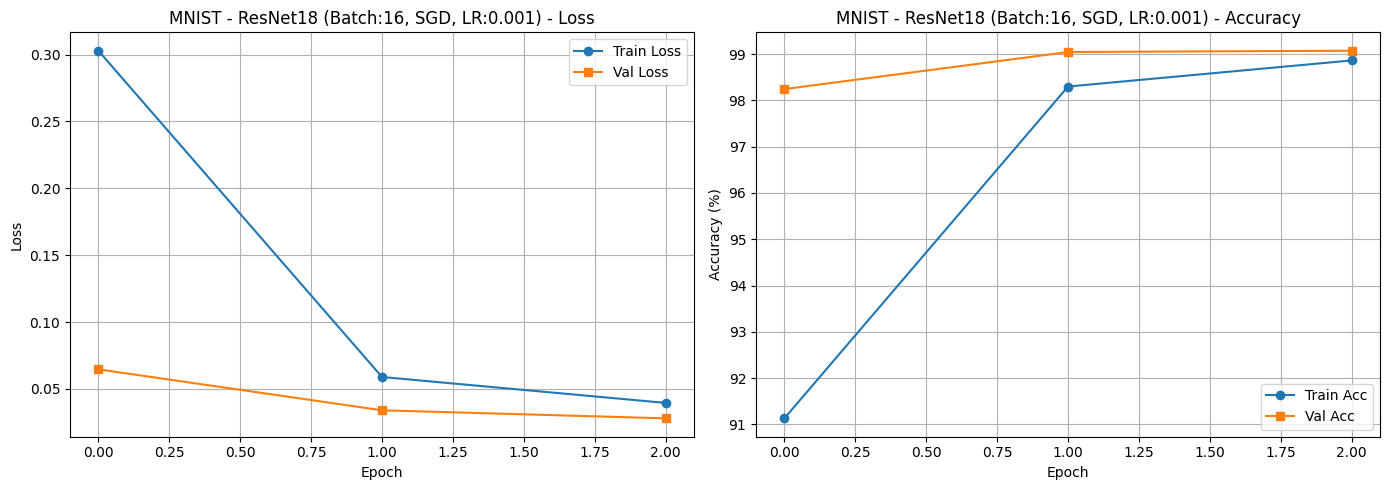


Experiment: MNIST | ResNet50 | Batch: 16 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.4195, Train Acc: 86.23%, Val Loss: 0.0706, Val Acc: 97.93%
Epoch 2/3: Train Loss: 0.0673, Train Acc: 97.93%, Val Loss: 0.0462, Val Acc: 98.51%
Epoch 3/3: Train Loss: 0.0431, Train Acc: 98.64%, Val Loss: 0.0364, Val Acc: 98.93%

Test Accuracy: 98.81%


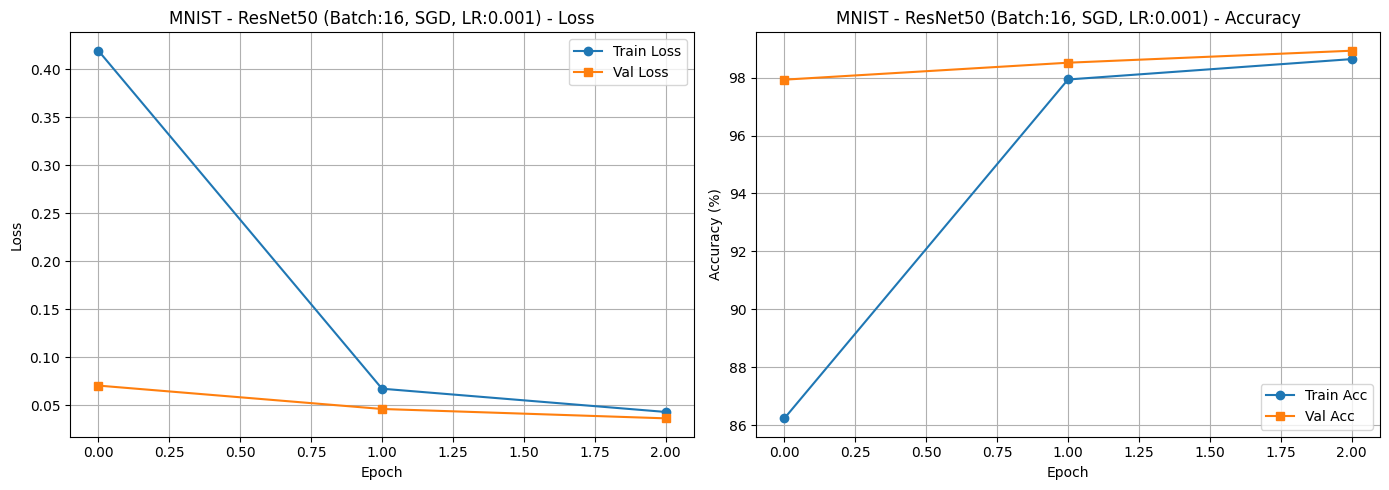


Experiment: MNIST | ResNet18 | Batch: 16 | Opt: SGD | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 1.3246, Train Acc: 65.84%, Val Loss: 0.4579, Val Acc: 92.20%
Epoch 2/3: Train Loss: 0.3386, Train Acc: 92.66%, Val Loss: 0.1660, Val Acc: 96.47%
Epoch 3/3: Train Loss: 0.1803, Train Acc: 95.65%, Val Loss: 0.1132, Val Acc: 97.14%

Test Accuracy: 97.09%


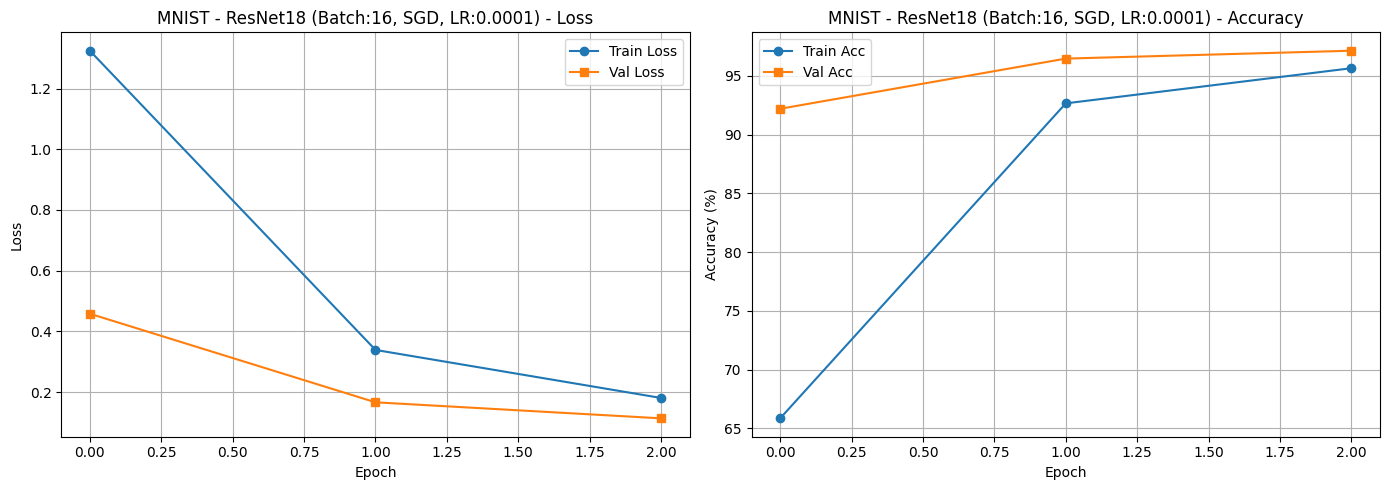


Experiment: MNIST | ResNet50 | Batch: 16 | Opt: SGD | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 1.6405, Train Acc: 43.19%, Val Loss: 1.0775, Val Acc: 69.04%
Epoch 2/3: Train Loss: 0.6421, Train Acc: 82.67%, Val Loss: 0.2871, Val Acc: 92.73%
Epoch 3/3: Train Loss: 0.2651, Train Acc: 93.00%, Val Loss: 0.1417, Val Acc: 96.33%

Test Accuracy: 96.11%


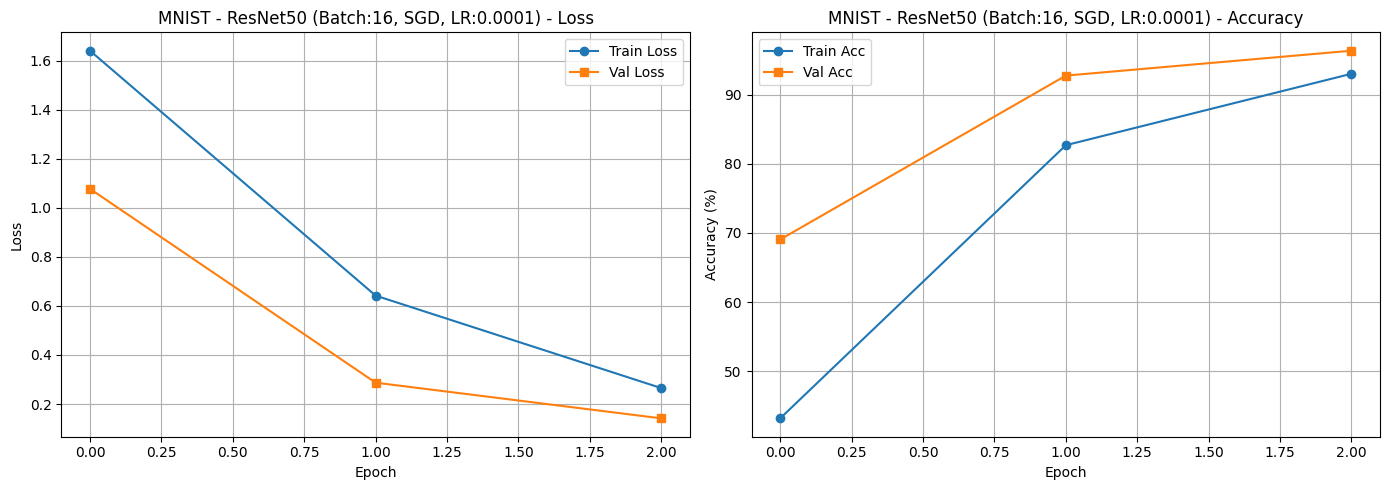


Experiment: MNIST | ResNet18 | Batch: 16 | Opt: Adam | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.1280, Train Acc: 96.18%, Val Loss: 0.0706, Val Acc: 97.86%
Epoch 2/3: Train Loss: 0.0550, Train Acc: 98.34%, Val Loss: 0.0462, Val Acc: 98.66%
Epoch 3/3: Train Loss: 0.0409, Train Acc: 98.74%, Val Loss: 0.0352, Val Acc: 98.93%

Test Accuracy: 98.71%


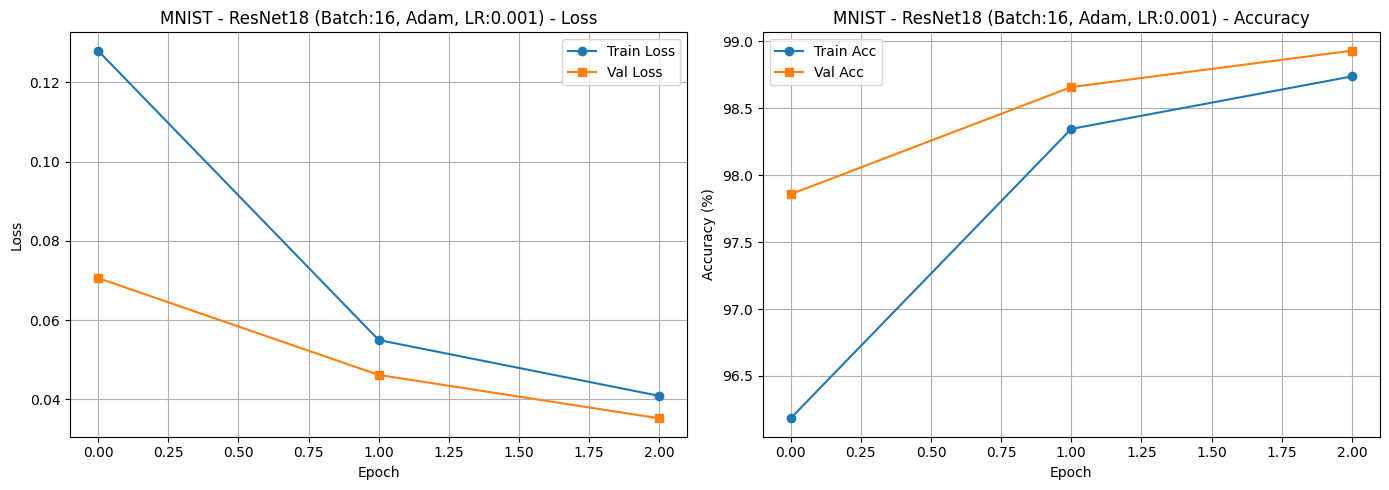


Experiment: MNIST | ResNet50 | Batch: 16 | Opt: Adam | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.2138, Train Acc: 93.69%, Val Loss: 0.1237, Val Acc: 96.56%
Epoch 2/3: Train Loss: 0.0927, Train Acc: 97.28%, Val Loss: 0.0663, Val Acc: 98.13%
Epoch 3/3: Train Loss: 0.0668, Train Acc: 98.06%, Val Loss: 0.0509, Val Acc: 98.59%

Test Accuracy: 98.41%


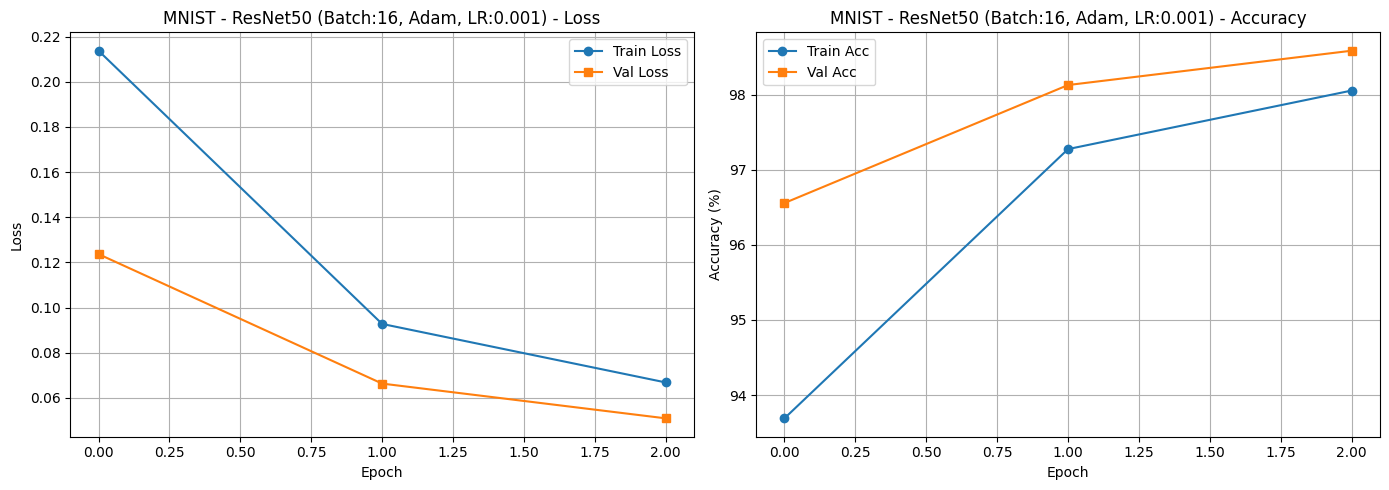


Experiment: MNIST | ResNet18 | Batch: 16 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.1263, Train Acc: 96.38%, Val Loss: 0.0464, Val Acc: 98.71%
Epoch 2/3: Train Loss: 0.0442, Train Acc: 98.66%, Val Loss: 0.0285, Val Acc: 99.17%
Epoch 3/3: Train Loss: 0.0340, Train Acc: 98.94%, Val Loss: 0.0228, Val Acc: 99.33%

Test Accuracy: 99.25%


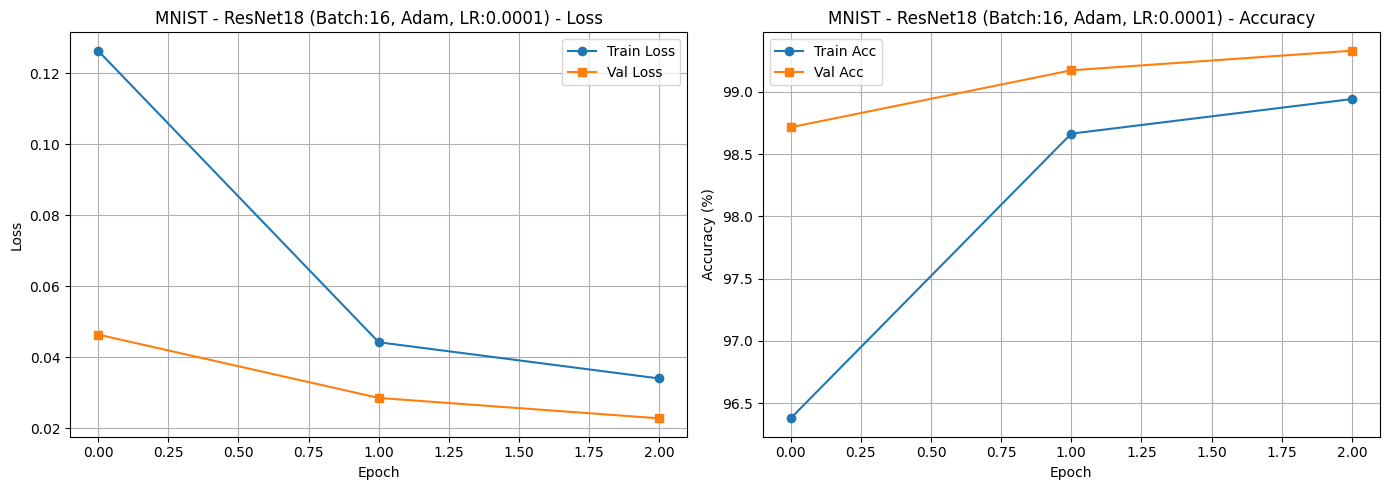


Experiment: MNIST | ResNet50 | Batch: 16 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.1972, Train Acc: 93.77%, Val Loss: 0.0541, Val Acc: 98.46%
Epoch 2/3: Train Loss: 0.0597, Train Acc: 98.15%, Val Loss: 0.0358, Val Acc: 98.94%
Epoch 3/3: Train Loss: 0.0468, Train Acc: 98.53%, Val Loss: 0.0367, Val Acc: 98.87%

Test Accuracy: 98.88%


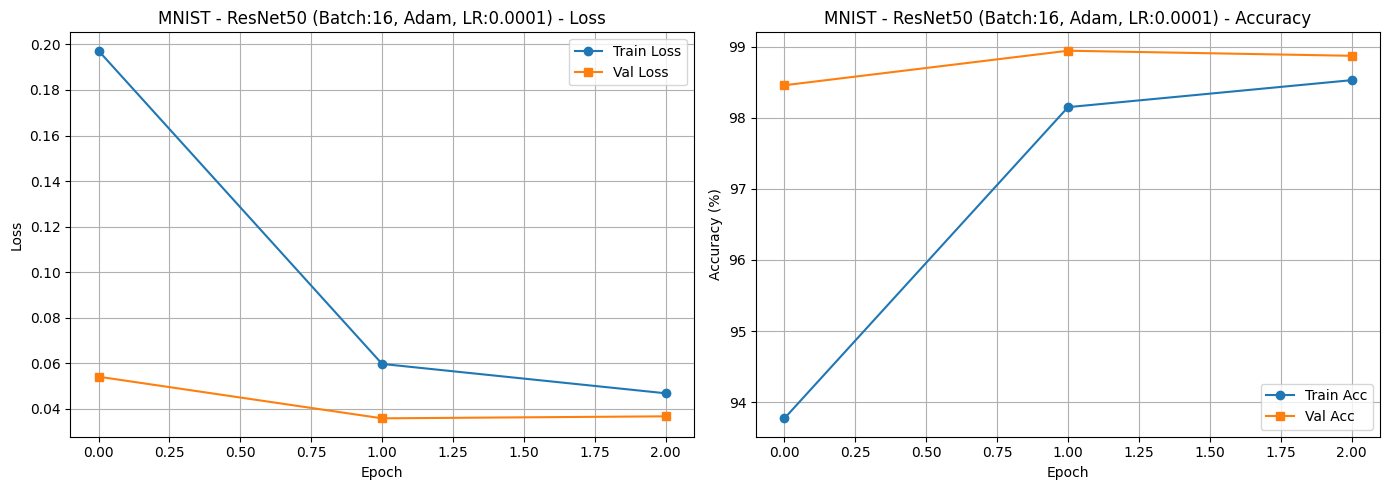


Experiment: MNIST | ResNet18 | Batch: 32 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.4470, Train Acc: 87.88%, Val Loss: 0.1184, Val Acc: 96.67%
Epoch 2/3: Train Loss: 0.0744, Train Acc: 97.95%, Val Loss: 0.0571, Val Acc: 98.44%
Epoch 3/3: Train Loss: 0.0478, Train Acc: 98.66%, Val Loss: 0.0475, Val Acc: 98.66%

Test Accuracy: 98.41%


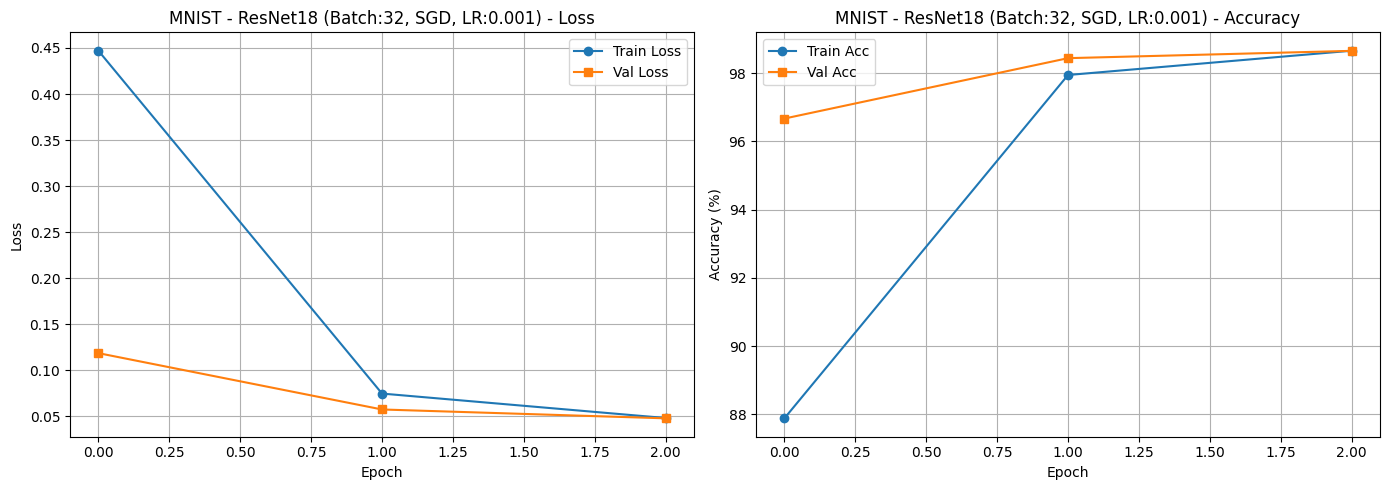


Experiment: MNIST | ResNet50 | Batch: 32 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.6101, Train Acc: 79.33%, Val Loss: 0.0895, Val Acc: 97.29%
Epoch 2/3: Train Loss: 0.0845, Train Acc: 97.49%, Val Loss: 0.0509, Val Acc: 98.51%
Epoch 3/3: Train Loss: 0.0482, Train Acc: 98.56%, Val Loss: 0.0472, Val Acc: 98.66%

Test Accuracy: 98.49%


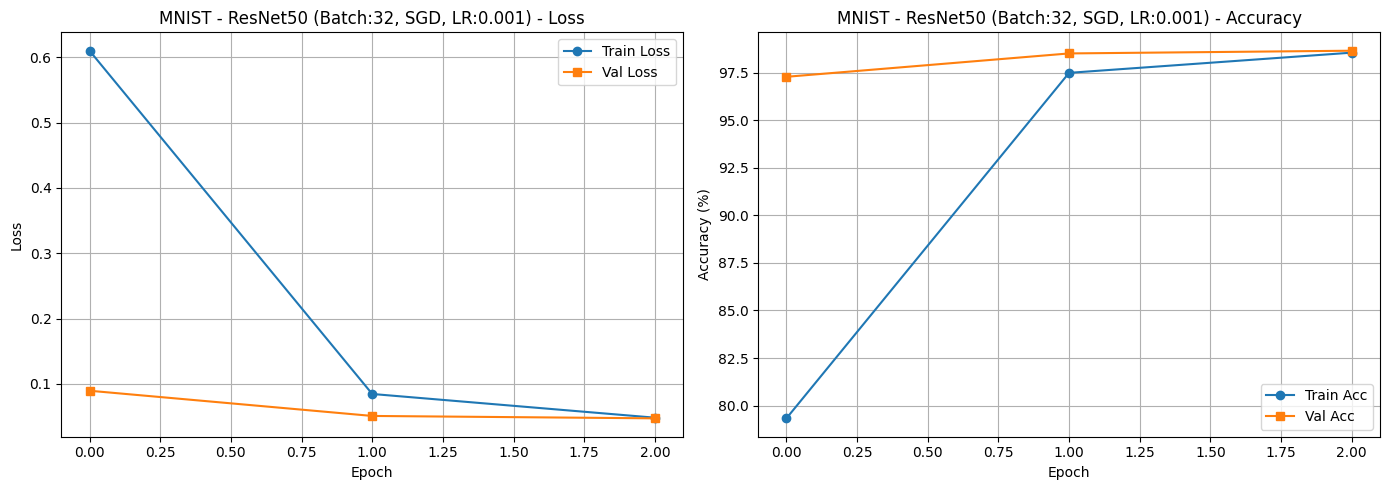


Experiment: MNIST | ResNet18 | Batch: 32 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.1349, Train Acc: 96.22%, Val Loss: 0.0491, Val Acc: 98.61%
Epoch 2/3: Train Loss: 0.0399, Train Acc: 98.80%, Val Loss: 0.0476, Val Acc: 98.69%
Epoch 3/3: Train Loss: 0.0267, Train Acc: 99.20%, Val Loss: 0.0235, Val Acc: 99.37%

Test Accuracy: 99.09%


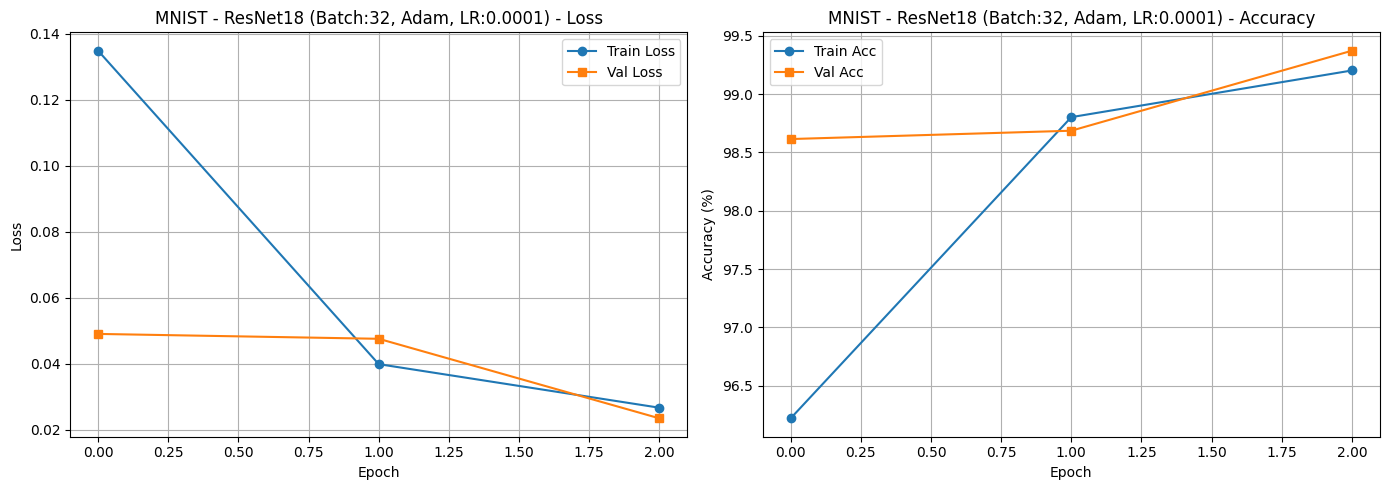


Experiment: MNIST | ResNet50 | Batch: 32 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.2015, Train Acc: 93.70%, Val Loss: 0.0653, Val Acc: 97.99%
Epoch 2/3: Train Loss: 0.0510, Train Acc: 98.42%, Val Loss: 0.0488, Val Acc: 98.64%
Epoch 3/3: Train Loss: 0.0372, Train Acc: 98.81%, Val Loss: 0.0803, Val Acc: 97.57%

Test Accuracy: 97.23%


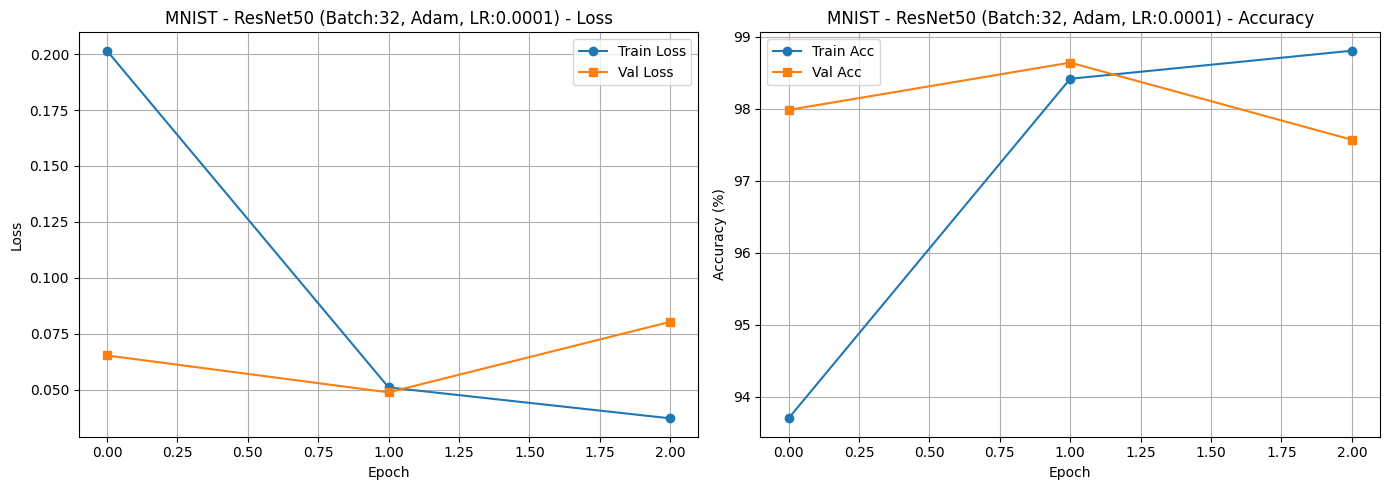

In [ ]:

mnist_experiments = [
    # Batch 16 experiments
    {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
    # Batch 32 experiments
    {'batch_size': 32, 'optimizer': 'SGD', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 32, 'optimizer': 'Adam', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
]

mnist_results = []
best_model_mnist = None
best_acc_mnist = 0

for exp in mnist_experiments:
    for model_name in ['ResNet18', 'ResNet50']:
        result, history, model = run_experiment_q1a(
            'MNIST', mnist_train, mnist_val, mnist_test,
            model_name, exp['batch_size'], exp['optimizer'],
            exp['lr'], exp['epochs'], exp['pin_memory']
        )
        mnist_results.append(result)

        # Track best model
        if result['Test Accuracy (%)'] > best_acc_mnist:
            best_acc_mnist = result['Test Accuracy (%)']
            best_model_mnist = (model, result)

### Running Q1(a) Experiments - FashionMNIST Dataset


Experiment: FashionMNIST | ResNet18 | Batch: 16 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.5800, Train Acc: 79.18%, Val Loss: 0.3726, Val Acc: 86.29%
Epoch 2/3: Train Loss: 0.3203, Train Acc: 88.50%, Val Loss: 0.2707, Val Acc: 90.21%
Epoch 3/3: Train Loss: 0.2586, Train Acc: 90.72%, Val Loss: 0.2335, Val Acc: 91.21%

Test Accuracy: 91.60%


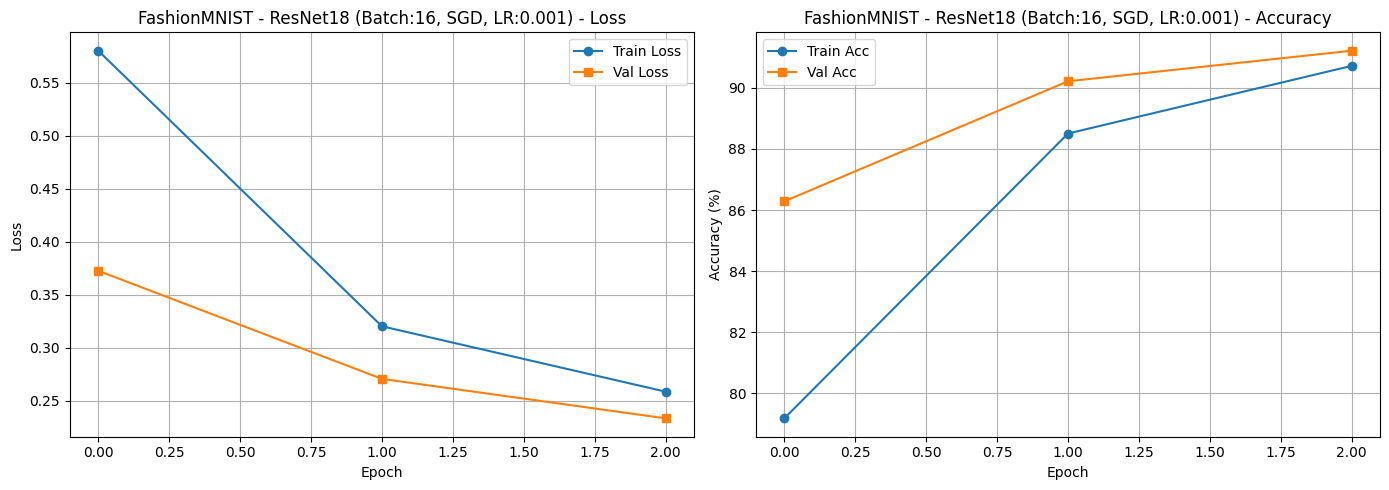


Experiment: FashionMNIST | ResNet50 | Batch: 16 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.8182, Train Acc: 70.18%, Val Loss: 0.4539, Val Acc: 83.91%
Epoch 2/3: Train Loss: 0.4030, Train Acc: 85.77%, Val Loss: 0.3515, Val Acc: 87.47%
Epoch 3/3: Train Loss: 0.3156, Train Acc: 88.90%, Val Loss: 0.3067, Val Acc: 88.96%

Test Accuracy: 88.96%


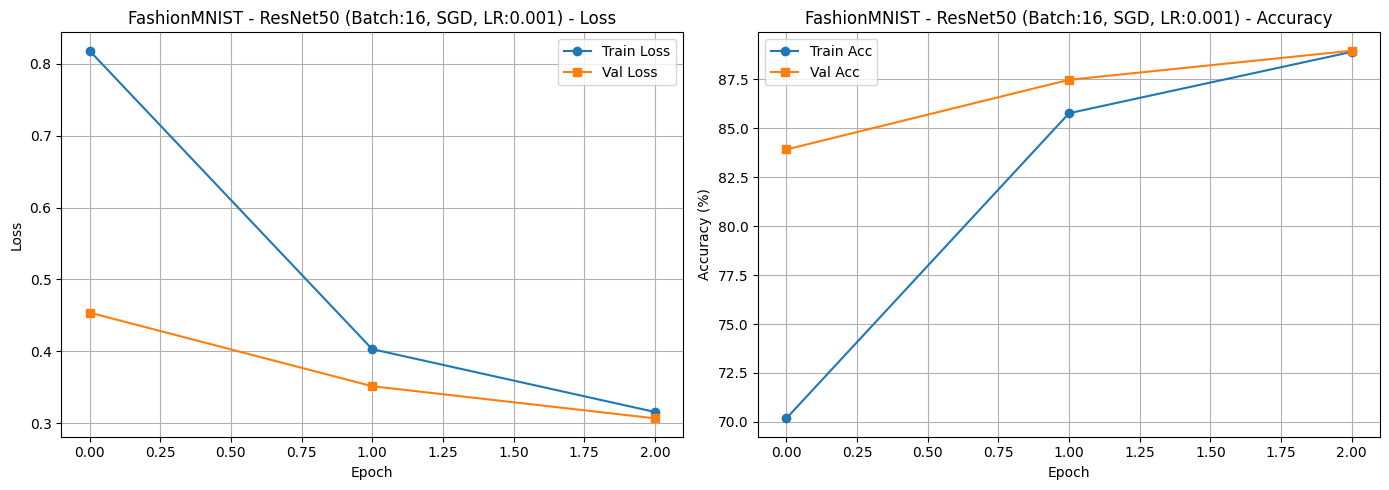


Experiment: FashionMNIST | ResNet18 | Batch: 16 | Opt: SGD | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 1.1724, Train Acc: 63.08%, Val Loss: 0.7361, Val Acc: 75.51%
Epoch 2/3: Train Loss: 0.6518, Train Acc: 77.38%, Val Loss: 0.5128, Val Acc: 82.10%
Epoch 3/3: Train Loss: 0.5084, Train Acc: 82.38%, Val Loss: 0.4204, Val Acc: 85.54%

Test Accuracy: 85.52%


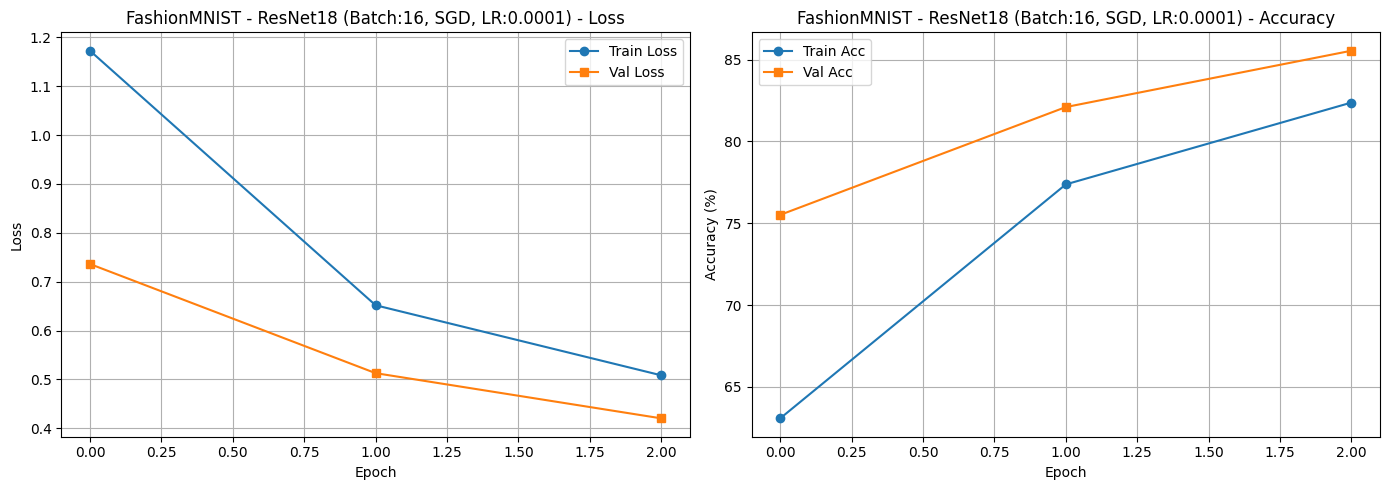


Experiment: FashionMNIST | ResNet50 | Batch: 16 | Opt: SGD | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 1.3924, Train Acc: 49.39%, Val Loss: 0.9054, Val Acc: 69.40%
Epoch 2/3: Train Loss: 0.8768, Train Acc: 68.55%, Val Loss: 0.6875, Val Acc: 75.14%
Epoch 3/3: Train Loss: 0.6954, Train Acc: 74.63%, Val Loss: 0.5596, Val Acc: 79.06%

Test Accuracy: 78.43%


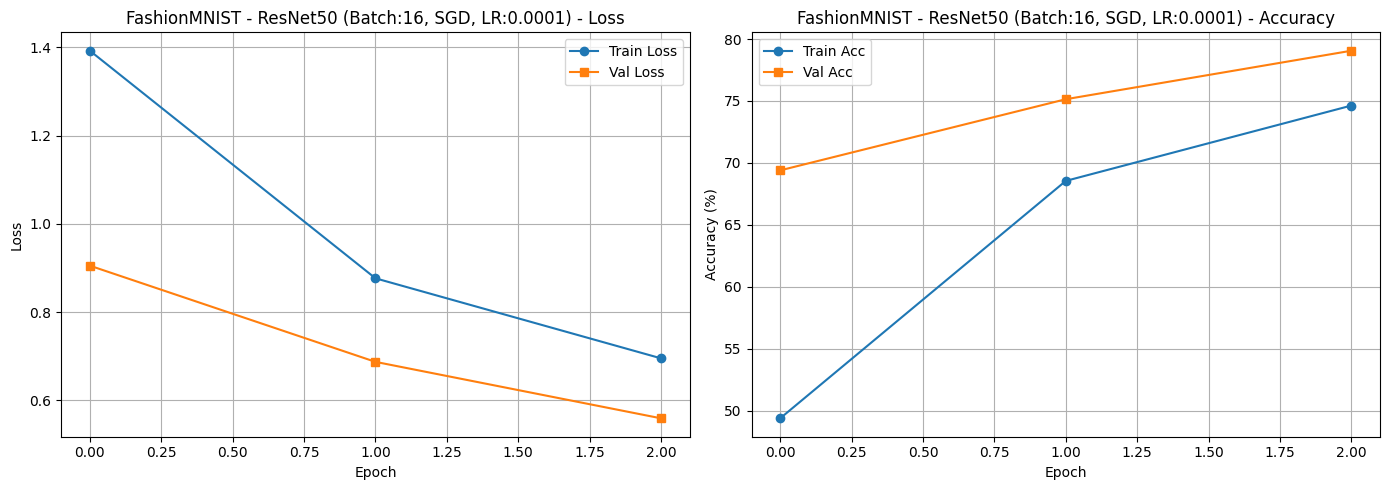


Experiment: FashionMNIST | ResNet18 | Batch: 16 | Opt: Adam | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.4781, Train Acc: 82.75%, Val Loss: 0.3278, Val Acc: 87.89%
Epoch 2/3: Train Loss: 0.2956, Train Acc: 89.28%, Val Loss: 0.2763, Val Acc: 89.60%
Epoch 3/3: Train Loss: 0.2431, Train Acc: 91.27%, Val Loss: 0.2223, Val Acc: 91.86%

Test Accuracy: 91.66%


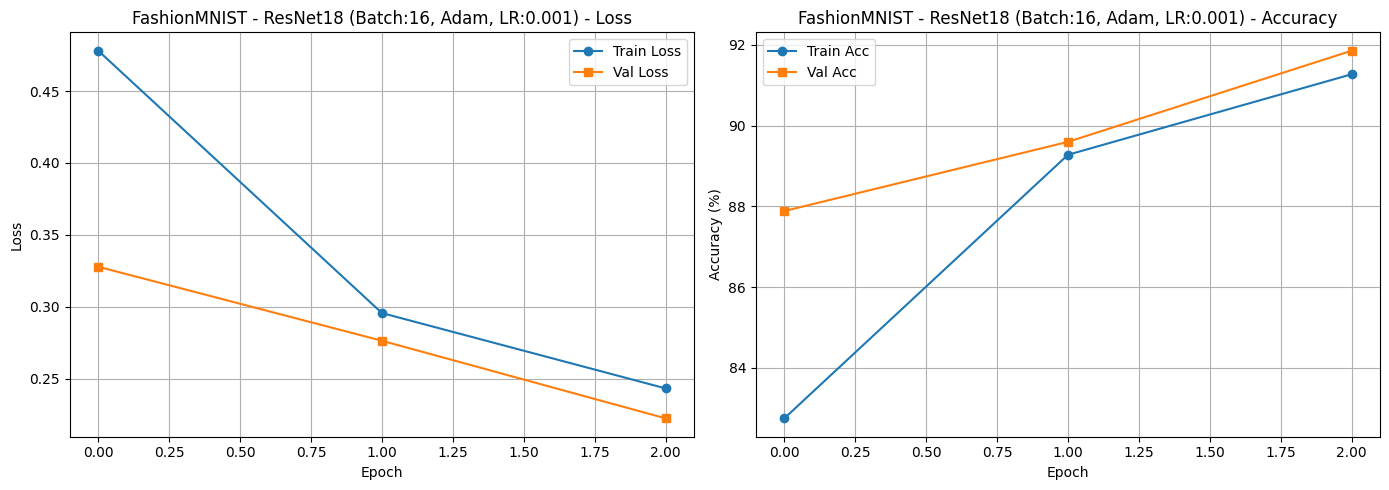


Experiment: FashionMNIST | ResNet50 | Batch: 16 | Opt: Adam | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.5858, Train Acc: 79.23%, Val Loss: 0.4302, Val Acc: 84.73%
Epoch 2/3: Train Loss: 0.3494, Train Acc: 87.55%, Val Loss: 0.3372, Val Acc: 87.44%
Epoch 3/3: Train Loss: 0.2918, Train Acc: 89.52%, Val Loss: 0.3066, Val Acc: 88.59%

Test Accuracy: 88.36%


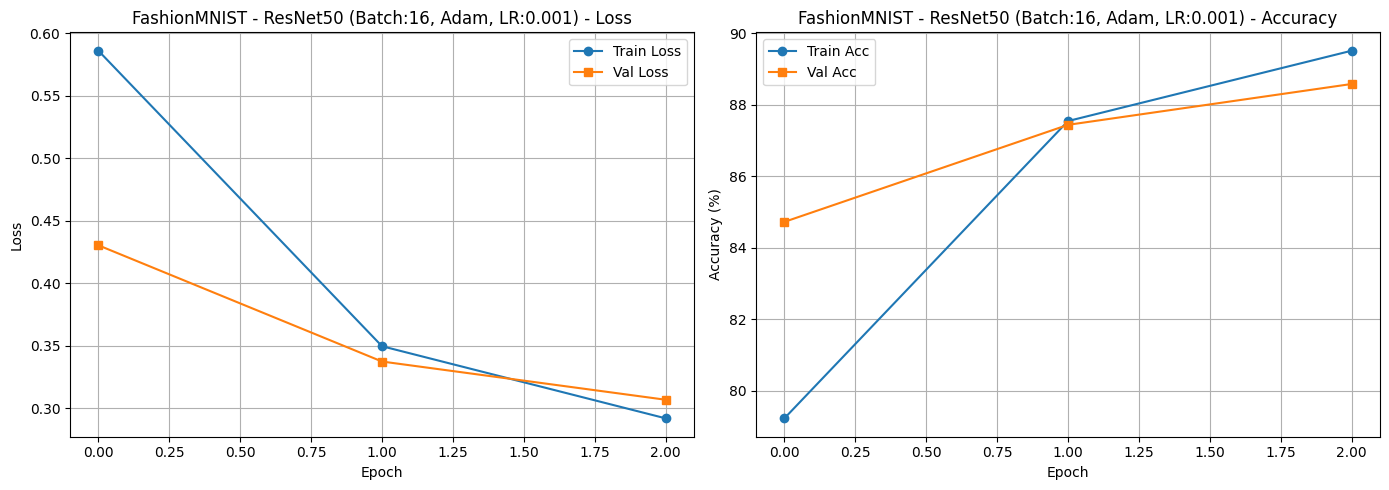


Experiment: FashionMNIST | ResNet18 | Batch: 16 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.4259, Train Acc: 84.84%, Val Loss: 0.2787, Val Acc: 89.46%
Epoch 2/3: Train Loss: 0.2619, Train Acc: 90.73%, Val Loss: 0.2432, Val Acc: 90.94%
Epoch 3/3: Train Loss: 0.2139, Train Acc: 92.36%, Val Loss: 0.2217, Val Acc: 91.79%

Test Accuracy: 92.07%


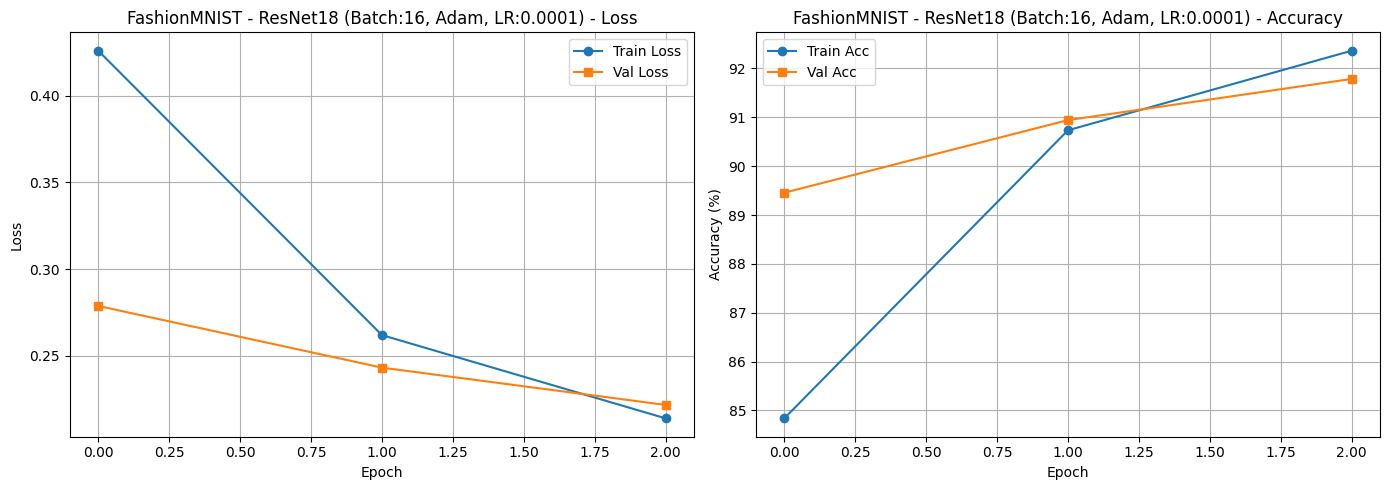


Experiment: FashionMNIST | ResNet50 | Batch: 16 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.5698, Train Acc: 78.76%, Val Loss: 0.3618, Val Acc: 86.94%
Epoch 2/3: Train Loss: 0.3166, Train Acc: 88.42%, Val Loss: 0.2601, Val Acc: 90.43%
Epoch 3/3: Train Loss: 0.2618, Train Acc: 90.57%, Val Loss: 0.2451, Val Acc: 91.11%

Test Accuracy: 91.34%


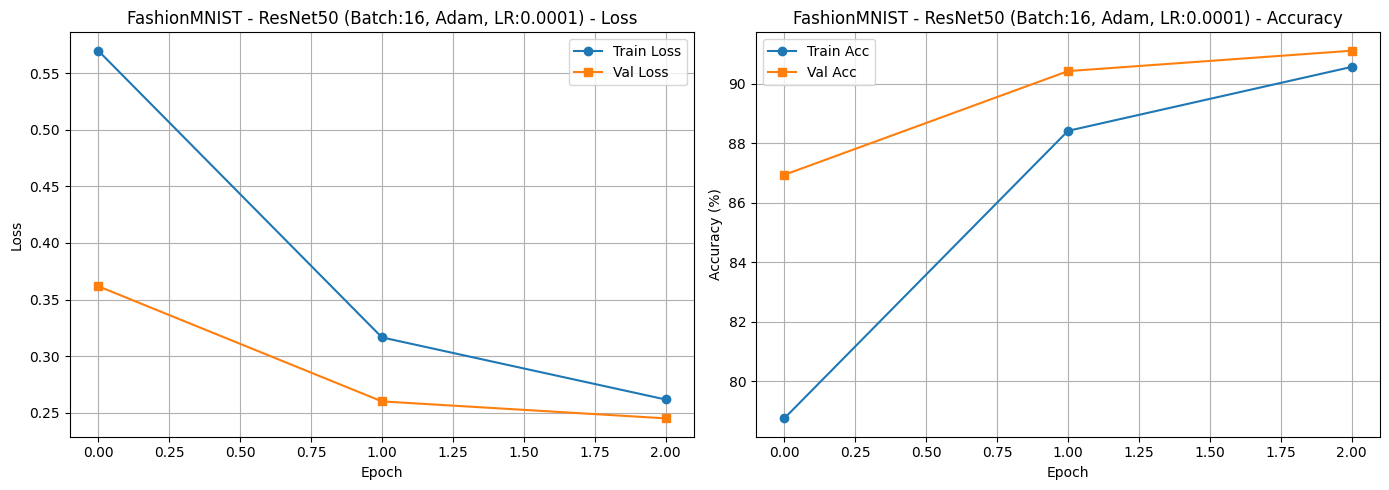


Experiment: FashionMNIST | ResNet18 | Batch: 32 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.6846, Train Acc: 75.83%, Val Loss: 0.3943, Val Acc: 86.29%
Epoch 2/3: Train Loss: 0.3563, Train Acc: 87.04%, Val Loss: 0.3283, Val Acc: 88.00%
Epoch 3/3: Train Loss: 0.2844, Train Acc: 89.86%, Val Loss: 0.2904, Val Acc: 89.50%

Test Accuracy: 89.41%


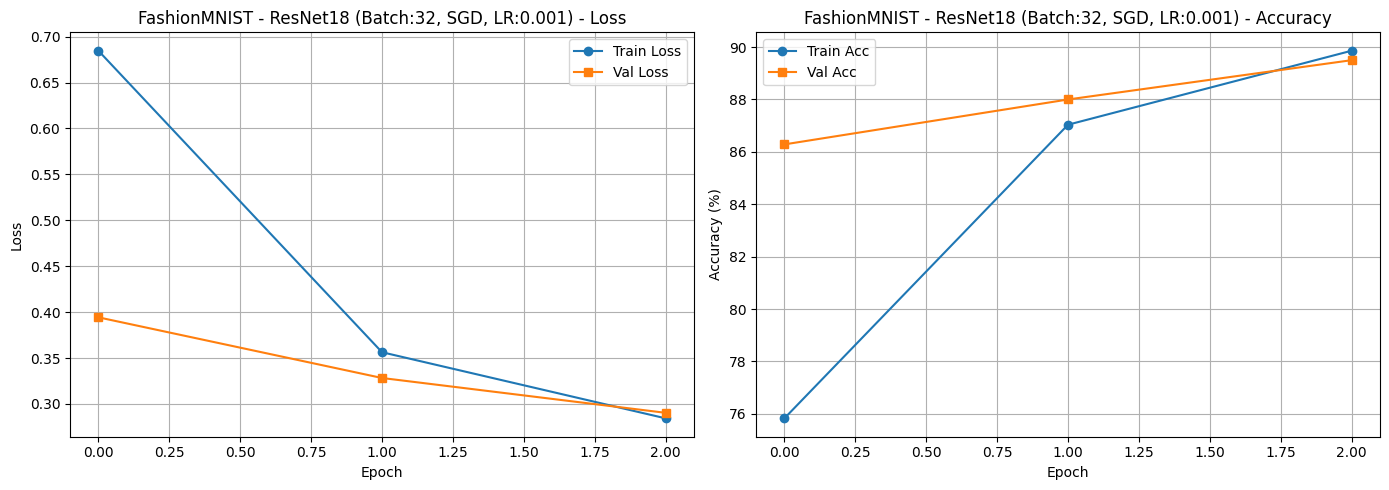


Experiment: FashionMNIST | ResNet50 | Batch: 32 | Opt: SGD | LR: 0.001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.9079, Train Acc: 66.38%, Val Loss: 0.5540, Val Acc: 80.61%
Epoch 2/3: Train Loss: 0.4612, Train Acc: 83.06%, Val Loss: 0.3653, Val Acc: 86.53%
Epoch 3/3: Train Loss: 0.3564, Train Acc: 87.18%, Val Loss: 0.3178, Val Acc: 88.29%

Test Accuracy: 88.08%


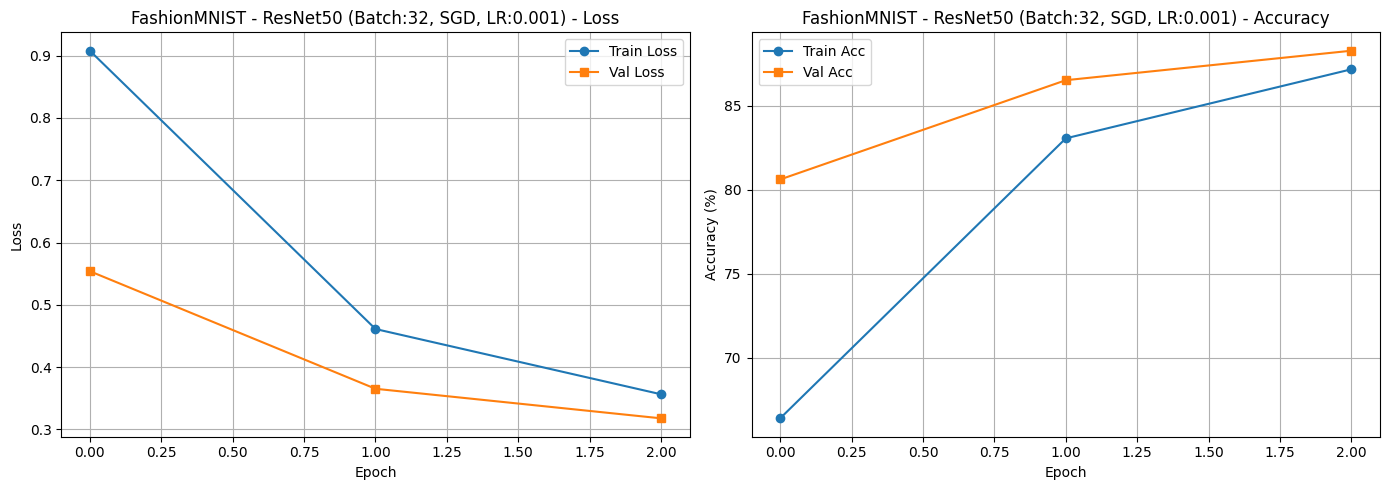


Experiment: FashionMNIST | ResNet18 | Batch: 32 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.4222, Train Acc: 84.73%, Val Loss: 0.2829, Val Acc: 90.03%
Epoch 2/3: Train Loss: 0.2568, Train Acc: 90.76%, Val Loss: 0.2945, Val Acc: 89.24%
Epoch 3/3: Train Loss: 0.2074, Train Acc: 92.44%, Val Loss: 0.2367, Val Acc: 91.34%

Test Accuracy: 91.57%


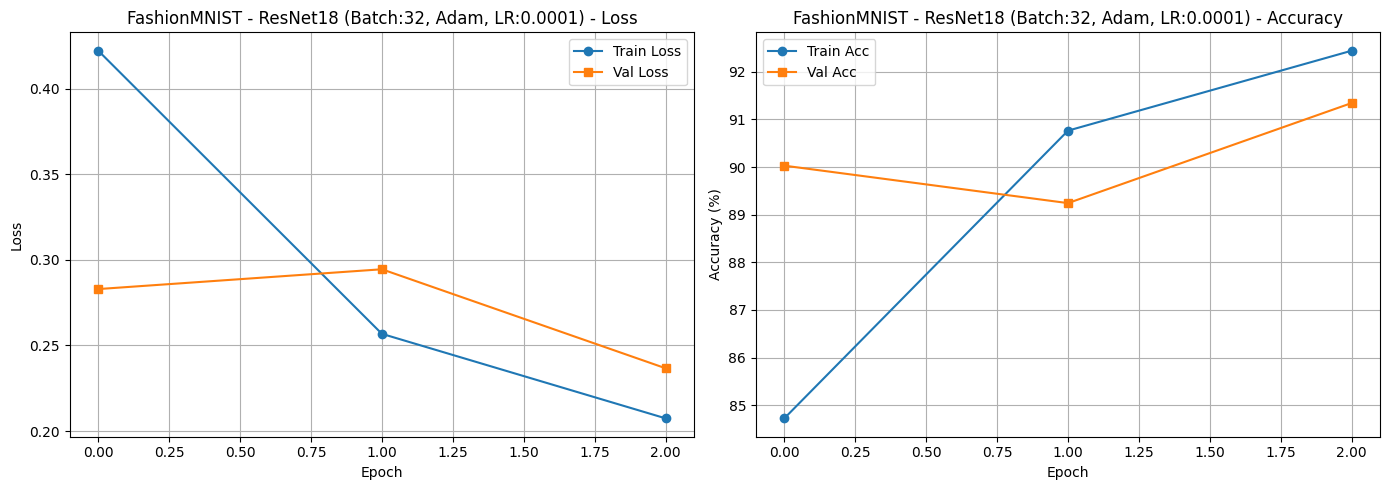


Experiment: FashionMNIST | ResNet50 | Batch: 32 | Opt: Adam | LR: 0.0001 | Epochs: 3 | pin_memory: True
Epoch 1/3: Train Loss: 0.5939, Train Acc: 77.81%, Val Loss: 0.3425, Val Acc: 87.13%
Epoch 2/3: Train Loss: 0.3304, Train Acc: 88.05%, Val Loss: 0.2910, Val Acc: 89.41%
Epoch 3/3: Train Loss: 0.2597, Train Acc: 90.61%, Val Loss: 0.2555, Val Acc: 91.09%

Test Accuracy: 90.89%


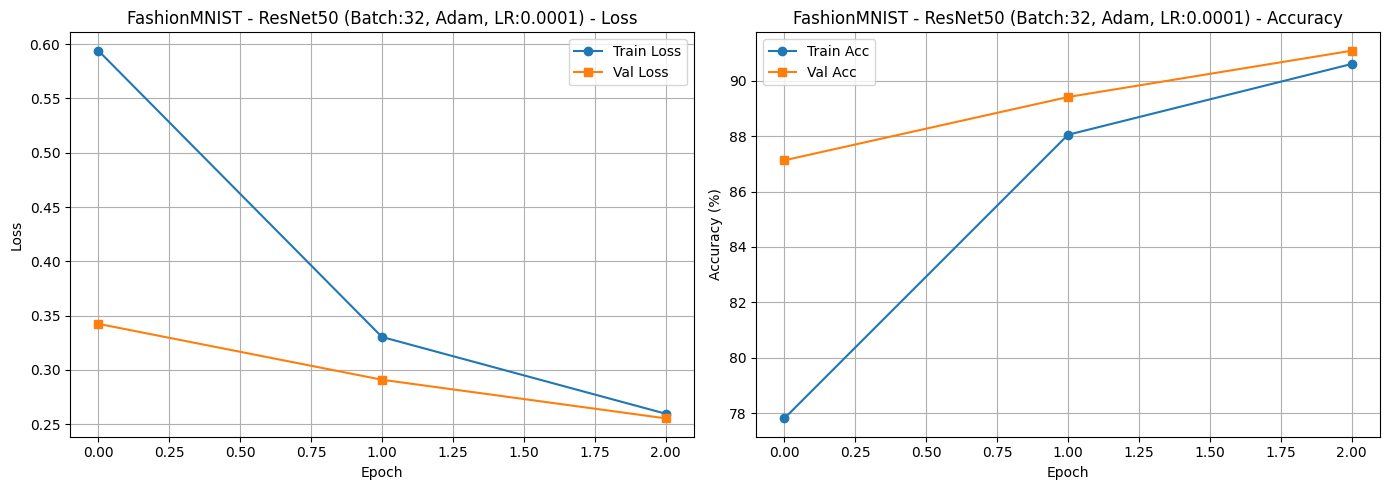

In [ ]:
# Q1(a) Experiments for FashionMNIST
fashion_experiments = [
    # Batch 16 experiments
    {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'SGD', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 16, 'optimizer': 'Adam', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
    # Batch 32 experiments
    {'batch_size': 32, 'optimizer': 'SGD', 'lr': 0.001, 'epochs': 3, 'pin_memory': True},
    {'batch_size': 32, 'optimizer': 'Adam', 'lr': 0.0001, 'epochs': 3, 'pin_memory': True},
]

fashion_results = []
best_model_fashion = None
best_acc_fashion = 0

for exp in fashion_experiments:
    for model_name in ['ResNet18', 'ResNet50']:
        result, history, model = run_experiment_q1a(
            'FashionMNIST', fashion_train, fashion_val, fashion_test,
            model_name, exp['batch_size'], exp['optimizer'],
            exp['lr'], exp['epochs'], exp['pin_memory']
        )
        fashion_results.append(result)

        # Track best model
        if result['Test Accuracy (%)'] > best_acc_fashion:
            best_acc_fashion = result['Test Accuracy (%)']
            best_model_fashion = (model, result)

### Q1(a) Results Summary

In [ ]:
# Combine all Q1(a) results
all_q1a_results = mnist_results + fashion_results
df_q1a = pd.DataFrame(all_q1a_results)

# Display results for MNIST
print("=" * 100)
print("Q1(a) RESULTS - MNIST DATASET")
print("=" * 100)
df_mnist = df_q1a[df_q1a['Dataset'] == 'MNIST']
print(df_mnist.to_string(index=False))

print("\n")
print("=" * 100)
print("Q1(a) RESULTS - FashionMNIST DATASET")
print("=" * 100)
df_fashion = df_q1a[df_q1a['Dataset'] == 'FashionMNIST']
print(df_fashion.to_string(index=False))

Q1(a) RESULTS - MNIST DATASET
Dataset    Model  Batch Size Optimizer  Learning Rate  Epochs  pin_memory  Test Accuracy (%)  Train Time (ms)  Final Val Acc (%)
  MNIST ResNet18          16       SGD         0.0010       3        True              99.11        395215.03              99.07
  MNIST ResNet50          16       SGD         0.0010       3        True              98.81        714489.22              98.93
  MNIST ResNet18          16       SGD         0.0001       3        True              97.09        389802.45              97.14
  MNIST ResNet50          16       SGD         0.0001       3        True              96.11        713614.67              96.33
  MNIST ResNet18          16      Adam         0.0010       3        True              98.71        398288.39              98.93
  MNIST ResNet50          16      Adam         0.0010       3        True              98.41        747441.42              98.59
  MNIST ResNet18          16      Adam         0.0001       3      

In [ ]:
# Create formatted table as per assignment requirements
print("\n" + "="*80)
print("FORMATTED RESULTS TABLE (As per Assignment)")
print("="*80)

# Pivot table for ResNet-18 vs ResNet-50 comparison
for dataset in ['MNIST', 'FashionMNIST']:
    print(f"\n{dataset} Dataset:")
    print("-" * 70)
    df_subset = df_q1a[df_q1a['Dataset'] == dataset]

    pivot_data = []
    for _, row in df_subset.iterrows():
        pivot_data.append({
            'Batch Size': row['Batch Size'],
            'Optimizer': row['Optimizer'],
            'Learning Rate': row['Learning Rate'],
            f"{row['Model']} Acc (%)":  row['Test Accuracy (%)']
        })

    # Group by hyperparameters
    grouped = df_subset.pivot_table(
        index=['Batch Size', 'Optimizer', 'Learning Rate'],
        columns='Model',
        values='Test Accuracy (%)',
        aggfunc='first'
    ).reset_index()
    print(grouped.to_string(index=False))


FORMATTED RESULTS TABLE (As per Assignment)

MNIST Dataset:
----------------------------------------------------------------------
 Batch Size Optimizer  Learning Rate  ResNet18  ResNet50
         16      Adam         0.0001     99.25     98.88
         16      Adam         0.0010     98.71     98.41
         16       SGD         0.0001     97.09     96.11
         16       SGD         0.0010     99.11     98.81
         32      Adam         0.0001     99.09     97.23
         32       SGD         0.0010     98.41     98.49

FashionMNIST Dataset:
----------------------------------------------------------------------
 Batch Size Optimizer  Learning Rate  ResNet18  ResNet50
         16      Adam         0.0001     92.07     91.34
         16      Adam         0.0010     91.66     88.36
         16       SGD         0.0001     85.52     78.43
         16       SGD         0.0010     91.60     88.96
         32      Adam         0.0001     91.57     90.89
         32       SGD         0.0

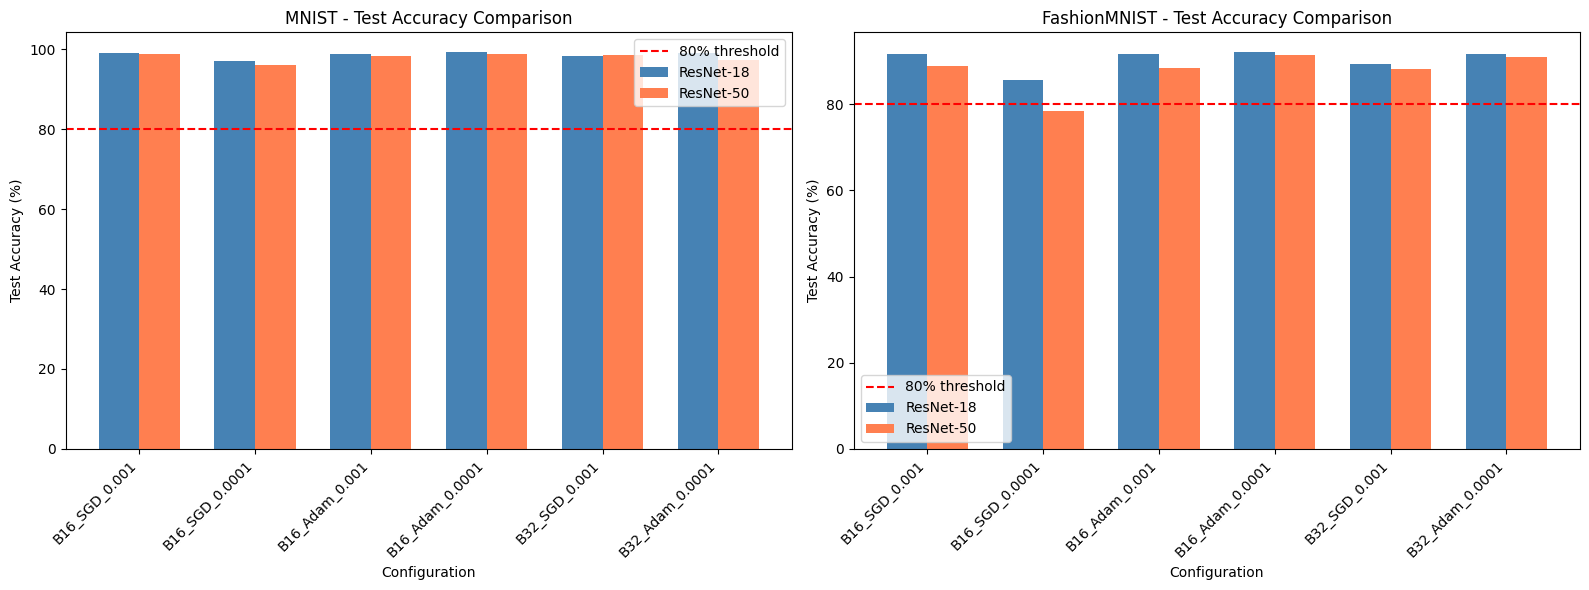

In [ ]:
# Visualization of Q1(a) Results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, dataset in enumerate(['MNIST', 'FashionMNIST']):
    df_subset = df_q1a[df_q1a['Dataset'] == dataset]

    x_labels = [f"B{row['Batch Size']}_{row['Optimizer']}_{row['Learning Rate']}"
                for _, row in df_subset.iterrows()]

    resnet18_acc = df_subset[df_subset['Model'] == 'ResNet18']['Test Accuracy (%)'].values
    resnet50_acc = df_subset[df_subset['Model'] == 'ResNet50']['Test Accuracy (%)'].values

    x = np.arange(len(resnet18_acc))
    width = 0.35

    axes[idx].bar(x - width/2, resnet18_acc, width, label='ResNet-18', color='steelblue')
    axes[idx].bar(x + width/2, resnet50_acc, width, label='ResNet-50', color='coral')

    axes[idx].set_xlabel('Configuration')
    axes[idx].set_ylabel('Test Accuracy (%)')
    axes[idx].set_title(f'{dataset} - Test Accuracy Comparison')
    axes[idx].axhline(y=80, color='r', linestyle='--', label='80% threshold')
    axes[idx].legend()
    axes[idx].set_xticks(x)
    unique_labels = list(dict.fromkeys(x_labels))[:len(resnet18_acc)]
    axes[idx].set_xticklabels(unique_labels, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('q1a_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Q1(b): SVM Classifier on MNIST and FashionMNIST

Training SVM with different kernels: 'poly', 'rbf'

In [ ]:
def load_flat_dataset(dataset_name='MNIST', max_samples=10000):
    """Load dataset as flattened arrays for SVM"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    if dataset_name == 'MNIST':
        train_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    # Convert to numpy and flatten
    X_train = train_data.data.numpy().reshape(-1, 28*28)[:max_samples].astype('float32') / 255.0
    y_train = train_data.targets.numpy()[:max_samples]
    X_test = test_data.data.numpy().reshape(-1, 28*28).astype('float32') / 255.0
    y_test = test_data.targets.numpy()

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, y_train, X_test, y_test

In [ ]:
def run_svm_experiment(dataset_name, kernel, max_samples=10000):
    """Run SVM experiment"""
    print(f"\nRunning SVM ({kernel}) on {dataset_name}...")

    X_train, y_train, X_test, y_test = load_flat_dataset(dataset_name, max_samples)

    # Train SVM
    svm = SVC(kernel=kernel, random_state=42)

    start_time = time.time()
    svm.fit(X_train, y_train)
    train_time = (time.time() - start_time) * 1000  # in ms

    # Evaluate
    y_pred = svm.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Training Time: {train_time:.2f} ms")

    return {
        'Dataset': dataset_name,
        'Kernel': kernel,
        'Test Accuracy (%)': round(accuracy, 2),
        'Training Time (ms)': round(train_time, 2)
    }

In [ ]:
# Run Q1(b) experiments
svm_results = []

for dataset in ['MNIST', 'FashionMNIST']:
    for kernel in ['poly', 'rbf']:
        result = run_svm_experiment(dataset, kernel, max_samples=10000)
        svm_results.append(result)

df_svm = pd.DataFrame(svm_results)


Running SVM (poly) on MNIST...
Test Accuracy: 90.56%
Training Time: 22215.67 ms

Running SVM (rbf) on MNIST...
Test Accuracy: 93.80%
Training Time: 11161.82 ms

Running SVM (poly) on FashionMNIST...
Test Accuracy: 82.67%
Training Time: 11526.57 ms

Running SVM (rbf) on FashionMNIST...
Test Accuracy: 85.30%
Training Time: 8846.74 ms



Q1(b) RESULTS - SVM CLASSIFIER
     Dataset Kernel  Test Accuracy (%)  Training Time (ms)
       MNIST   poly              90.56            22215.67
       MNIST    rbf              93.80            11161.82
FashionMNIST   poly              82.67            11526.57
FashionMNIST    rbf              85.30             8846.74


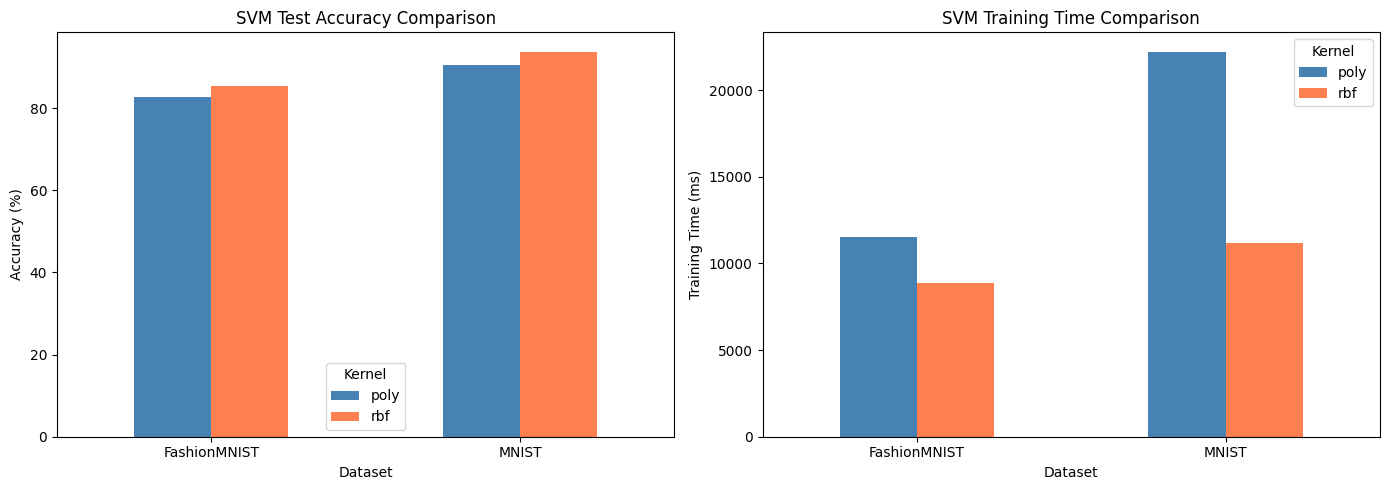

In [ ]:
# Q1(b) Results Summary
print("\n" + "="*80)
print("Q1(b) RESULTS - SVM CLASSIFIER")
print("="*80)
print(df_svm.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
pivot_acc = df_svm.pivot(index='Dataset', columns='Kernel', values='Test Accuracy (%)')
pivot_acc.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('SVM Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_xlabel('Dataset')
axes[0].legend(title='Kernel')
axes[0].tick_params(axis='x', rotation=0)

# Training time comparison
pivot_time = df_svm.pivot(index='Dataset', columns='Kernel', values='Training Time (ms)')
pivot_time.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('SVM Training Time Comparison')
axes[1].set_ylabel('Training Time (ms)')
axes[1].set_xlabel('Dataset')
axes[1].legend(title='Kernel')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('q1b_svm_results.png', dpi=150, bbox_inches='tight')
plt.show()